# 05 - Segmentation, Cutoff & Profitability Analysis

- Customer segmentation theo dai risk score (3-5 nhom)
- Cutoff analysis: approval rate, bad rate, Expected Net Return
- Business rules override
- Chuan bi du lieu cho Dashboard

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from src.paths import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS, REPORTS_FIGURES, DASHBOARDS

## Segmentation theo risk score

In [2]:
import numpy as np
import pickle
from scipy.stats import chi2_contingency

val_df = pd.read_parquet(DATA_PROCESSED / 'val.parquet')
test_df = pd.read_parquet(DATA_PROCESSED / 'test.parquet')

with open(MODELS / 'primary_model.txt') as f:
    primary_model_name = f.read().strip()
print('Model chinh:', primary_model_name)


def score_df(df):
    # Lay danh sach feature TRUC TIEP tu model artifact (gbm.feature_name() / lr.feature_names_in_)
    # thay vi doan lai tu toan bo cot *_woe trong processed data - so feature model 04 thuc su
    # dung co the it hon candidate set day du (vd sau khi cat bot theo SHAP), doan sai se lam
    # predict() bao loi lech so cot so voi luc train.
    if primary_model_name == 'LightGBM':
        import lightgbm as lgb
        gbm = lgb.Booster(model_file=str(MODELS / 'lightgbm_model.txt'))
        raw_features = gbm.feature_name()
        cat_features = [c for c in raw_features if not pd.api.types.is_numeric_dtype(df[c])]
        X_score = df[raw_features].copy()
        for c in cat_features:
            X_score[c] = X_score[c].astype('category')
        return gbm.predict(X_score)
    with open(MODELS / 'logistic_regression_woe.pkl', 'rb') as f:
        lr = pickle.load(f)
    return lr.predict_proba(df[list(lr.feature_names_in_)])[:, 1]


val_df = val_df.copy()
test_df = test_df.copy()
val_df['pd_score'] = score_df(val_df)    # score = P(bad) - cao hon = rui ro cao hon
test_df['pd_score'] = score_df(test_df)

# Ranh gioi segment/cutoff/business rule o cell nay va cac cell duoi day deu QUYET DINH tren
# VALIDATION, chi BAO CAO ket qua tren TEST - tranh dung chinh tap se dung de bao cao ket qua
# de chon nguong (se lam con so bao cao lac quan hon thuc te).
N_SEGMENTS = 5
_, segment_edges = pd.qcut(val_df['pd_score'], N_SEGMENTS, retbins=True)
segment_edges[0], segment_edges[-1] = -np.inf, np.inf  # tranh lot segment voi diem test ngoai khoang cua val
segment_labels = [f'S{i+1}' for i in range(N_SEGMENTS)]
test_df['segment'] = pd.cut(test_df['pd_score'], bins=segment_edges, labels=segment_labels)

segment_summary = test_df.groupby('segment', observed=True).agg(
    n=('bad_flag', 'size'),
    bad_rate=('bad_flag', 'mean'),
    avg_pd_score=('pd_score', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
).reset_index()
print(segment_summary.to_string(index=False))

# Kiem dinh chi-square: default rate co tach biet co y nghia thong ke giua cac segment khong
contingency = pd.crosstab(test_df['segment'], test_df['bad_flag'])
chi2, p_value, _, _ = chi2_contingency(contingency)
print(f'\nChi-square segment vs bad_flag: chi2={chi2:.2f}, p={p_value:.6f}')
print('-> Default rate tach biet co y nghia thong ke giua cac segment.' if p_value < 0.05
      else '-> CANH BAO: khong co bang chung default rate khac biet giua cac segment.')

Model chinh: LightGBM


segment     n  bad_rate  avg_pd_score  avg_loan_amnt  avg_int_rate
     S1 24847  0.066084      0.055236   11547.561074      8.776852
     S2 21272  0.135389      0.111931   11410.858170     11.580307
     S3 20200  0.194653      0.162923   11703.771040     13.126668
     S4 19709  0.258004      0.225975   12278.456543     14.588267
     S5 19176  0.388037      0.349711   13760.560075     16.842495

Chi-square segment vs bad_flag: chi2=8012.81, p=0.000000
-> Default rate tach biet co y nghia thong ke giua cac segment.


## Population Stability Index (PSI)

In [3]:
# PSI: kiem tra do on dinh phan phoi diem so giua cac giai doan thoi gian (train = som nhat,
# val = giua, test = muon nhat theo issue_d) - danh gia model co "trot" (drift) qua thoi gian,
# co can hieu chinh lai (recalibrate) khong neu dung lien tuc qua nhieu vintage (xem "Gioi han
# cua mo hinh" trong final_recommendation.md ve vintage effect). Nguong dien hinh nganh credit
# risk: <0.10 on dinh, 0.10-0.25 lech vua (theo doi), >=0.25 lech dang ke (can recalibrate).
train_df = pd.read_parquet(DATA_PROCESSED / 'train.parquet')
train_df = train_df.copy()
train_df['pd_score'] = score_df(train_df)


def compute_psi(expected, actual, n_bins=10):
    bin_edges = np.unique(np.quantile(expected, np.linspace(0, 1, n_bins + 1)))
    bin_edges[0], bin_edges[-1] = -np.inf, np.inf
    expected_pct = pd.cut(expected, bins=bin_edges).value_counts(normalize=True, sort=False).sort_index()
    actual_pct = pd.cut(actual, bins=bin_edges).value_counts(normalize=True, sort=False).sort_index()
    expected_pct = expected_pct.clip(lower=1e-4)
    actual_pct = actual_pct.clip(lower=1e-4)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())


def psi_verdict(psi):
    if psi < 0.10:
        return 'on dinh'
    if psi < 0.25:
        return 'lech vua - theo doi'
    return 'lech dang ke - can recalibrate'


psi_table = pd.DataFrame([
    {'comparison': 'train -> val', 'psi': compute_psi(train_df['pd_score'], val_df['pd_score'])},
    {'comparison': 'train -> test', 'psi': compute_psi(train_df['pd_score'], test_df['pd_score'])},
    {'comparison': 'val -> test', 'psi': compute_psi(val_df['pd_score'], test_df['pd_score'])},
])
psi_table['verdict'] = psi_table['psi'].apply(psi_verdict)
print(psi_table.to_string(index=False))
psi_table.to_csv(REPORTS_FIGURES / 'psi_report.csv', index=False)

   comparison      psi verdict
 train -> val 0.033496 on dinh
train -> test 0.010805 on dinh
  val -> test 0.009961 on dinh


## Cutoff / profitability analysis

LGD thuc te (1 - von goc thu hoi / von goc giai ngan, cac khoan Charged Off vintage 2015-2017): 58.87%


De xuat cutoff (toi da hoa Net Return UPLIFT so voi ngau nhien, tren VALIDATION): pd_score <= 0.19
cutoff                         1.900000e-01
approval_rate                  5.964450e-01
n_approved                     5.905700e+04
bad_rate_approved              1.363598e-01
interest_income                1.990197e+08
expected_loss                  5.792221e+07
expected_net_return            1.410974e+08
random_net_return              1.297286e+08
net_return_uplift_vs_random    1.136885e+07



[TEST] Tai approval rate ~78.3%: bad rate theo score = 15.20% vs. bad rate duyet ngau nhien (= bad rate quan the) = 19.94%

[TEST] Ket qua tai cutoff da chon tu validation (pd_score <= 0.19):
cutoff                                     0.19
approval_rate                          0.626925
n_approved                                65955
bad_rate_approved                      0.127026
interest_income                  208421070.0825
expected_loss                   59975794.090949
expected_net_return            148445275.991551
random_net_return              150326439.246339
net_return_uplift_vs_random     -1881163.254788
is_recommended_cutoff                      True


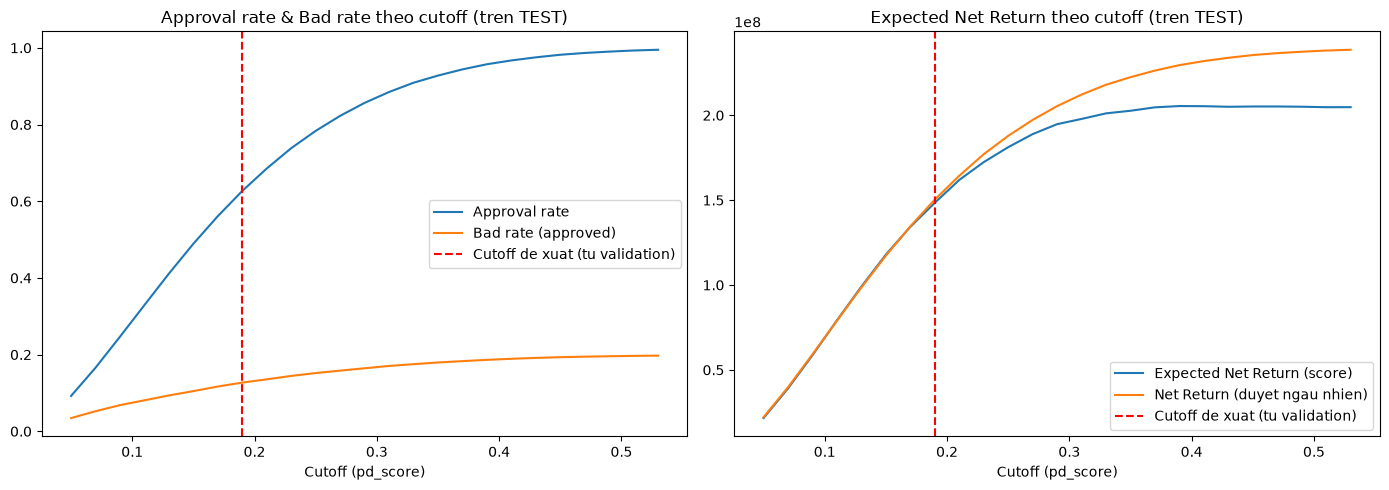

In [4]:
import matplotlib.pyplot as plt
from src.data.filter_vintage import filter_vintage
from src.paths import ACCEPTED_RAW

# --- LGD thuc te (aggregate, KHONG dung lam feature model - xem BRD.md muc 4 / PROPOSAL 4.3:
# chi cam dung leakage columns lam PREDICTOR, khong cam do luong outcome tai chinh thuc te) ---
usecols = ['loan_amnt', 'funded_amnt', 'term', 'issue_d', 'loan_status', 'total_rec_prncp', 'recoveries']
raw_chunks = [filter_vintage(chunk) for chunk in pd.read_csv(
    ACCEPTED_RAW, usecols=usecols, chunksize=200_000, low_memory=False
)]
raw_outcome = pd.concat(raw_chunks, ignore_index=True)

charged_off = raw_outcome[raw_outcome['loan_status'] == 'Charged Off']
total_funded = charged_off['funded_amnt'].sum()
total_principal_recovered = (charged_off['total_rec_prncp'] + charged_off['recoveries']).sum()
LGD = float(np.clip(1 - total_principal_recovered / total_funded, 0, 1))
print(f'LGD thuc te (1 - von goc thu hoi / von goc giai ngan, cac khoan Charged Off vintage 2015-2017): {LGD:.2%}')

# Scope PROPOSAL muc 4.2 chi giu ky han 36 thang (term la hang so, da bi loai khoi feature set vi
# khong con phuong sai) -> lai thu duoc tinh tren toan bo 3 nam vay, khong phai 1 ky nhu ban truoc.
TERM_YEARS = 3


# Expected Net Return = Sigma(int_rate x loan_amnt x TERM_YEARS, nhom Good duoc duyet) -
# Sigma(loan_amnt x LGD, nhom Bad duoc duyet). Van la don gian hoa so voi dong tien thuc te (lai
# don, khong chiet khau theo thoi gian, khong tinh truong hop tra som/currently delinquent) nhung
# da sua diem sai truoc do (lai 1 ky) theo dung ky han thuc te cua khoan vay trong scope du an.
def sweep_cutoffs(df, lgd, term_years):
    n_total = len(df)
    baseline_bad_rate = df['bad_flag'].mean()
    avg_int_rate = df['int_rate'].mean() / 100
    avg_loan_amnt = df['loan_amnt'].mean()
    rows = []
    for cutoff in np.arange(0.05, 0.55, 0.02):
        approved = df[df['pd_score'] <= cutoff]
        if len(approved) == 0:
            continue
        good = approved[approved['bad_flag'] == 0]
        bad = approved[approved['bad_flag'] == 1]
        interest_income = (good['int_rate'] / 100 * good['loan_amnt'] * term_years).sum()
        expected_loss = (bad['loan_amnt'] * lgd).sum()
        n_approved = len(approved)
        random_net_return = n_approved * (
            (1 - baseline_bad_rate) * avg_int_rate * term_years * avg_loan_amnt
            - baseline_bad_rate * avg_loan_amnt * lgd
        )
        rows.append({
            'cutoff': round(cutoff, 2),
            'approval_rate': n_approved / n_total,
            'n_approved': n_approved,
            'bad_rate_approved': approved['bad_flag'].mean(),
            'interest_income': interest_income,
            'expected_loss': expected_loss,
            'expected_net_return': interest_income - expected_loss,
            'random_net_return': random_net_return,
        })
    out = pd.DataFrame(rows)
    out['net_return_uplift_vs_random'] = out['expected_net_return'] - out['random_net_return']
    return out


# --- Chon cutoff: sweep + argmax tren VALIDATION, KHONG tren test - neu toi uu hoa truc tiep tren
# test roi lai bao cao ket qua tren chinh test, con so se lac quan hon thuc te (test khong con la
# du lieu "chua thay" doi voi quyet dinh nay). ---
#
# QUAN TRONG - phat hien khi sua TERM_YEARS (xem 2 o tren): argmax theo Expected Net Return TUYET
# DOI khong con hop ly sau khi nhan lai 3 nam - vi tong lai thu tang manh theo KHOI LUONG duyet,
# argmax bi keo ve phia duyet gan het ho so (approval rate ~97%), du uplift so voi duyet ngau
# nhien o do AM rat sau (mo hinh khong con tao gia tri gi so voi khong dung score). Day dung la
# cai bay ma business_rules_policy.md muc 1 da canh bao truoc ("so sanh tuong doi giua cac cutoff,
# khong phai con so loi nhuan tuyet doi chinh xac") nhung code truoc do chua ap dung dung canh bao
# nay. Sua: chon cutoff theo argmax UPLIFT so voi duyet ngau nhien (net_return_uplift_vs_random) -
# day moi la thuoc do gia tri tang them thuc su cua risk score, khong bi nhieu boi khoi luong.
val_cutoff_table = sweep_cutoffs(val_df, LGD, TERM_YEARS)
best_idx = val_cutoff_table['net_return_uplift_vs_random'].idxmax()
recommended_cutoff = float(val_cutoff_table.loc[best_idx, 'cutoff'])
print(f'De xuat cutoff (toi da hoa Net Return UPLIFT so voi ngau nhien, tren VALIDATION): '
      f'pd_score <= {recommended_cutoff}')
print(val_cutoff_table.loc[best_idx].to_string())

# --- Bao cao cuoi cung: sweep tren TEST (out-of-sample, khong dung de chon cutoff) de ve duong
# cong day du cho nguoi dung dashboard tham khao, va danh dau diem cutoff da chon o buoc tren. ---
cutoff_table = sweep_cutoffs(test_df, LGD, TERM_YEARS)
cutoff_table['is_recommended_cutoff'] = np.isclose(cutoff_table['cutoff'], recommended_cutoff)

baseline_bad_rate_test = test_df['bad_flag'].mean()
target_approval = 0.80
idx_80 = (cutoff_table['approval_rate'] - target_approval).abs().idxmin()
row_80 = cutoff_table.loc[idx_80]
print(f"\n[TEST] Tai approval rate ~{row_80['approval_rate']:.1%}: bad rate theo score = "
      f"{row_80['bad_rate_approved']:.2%} vs. bad rate duyet ngau nhien (= bad rate quan the) = "
      f"{baseline_bad_rate_test:.2%}")

recommended = cutoff_table.loc[cutoff_table['is_recommended_cutoff']].iloc[0]
print(f"\n[TEST] Ket qua tai cutoff da chon tu validation (pd_score <= {recommended_cutoff}):")
print(recommended.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cutoff_table['cutoff'], cutoff_table['approval_rate'], label='Approval rate')
axes[0].plot(cutoff_table['cutoff'], cutoff_table['bad_rate_approved'], label='Bad rate (approved)')
axes[0].axvline(recommended_cutoff, color='red', linestyle='--', label='Cutoff de xuat (tu validation)')
axes[0].set_xlabel('Cutoff (pd_score)')
axes[0].legend()
axes[0].set_title('Approval rate & Bad rate theo cutoff (tren TEST)')

axes[1].plot(cutoff_table['cutoff'], cutoff_table['expected_net_return'], label='Expected Net Return (score)')
axes[1].plot(cutoff_table['cutoff'], cutoff_table['random_net_return'], label='Net Return (duyet ngau nhien)')
axes[1].axvline(recommended_cutoff, color='red', linestyle='--', label='Cutoff de xuat (tu validation)')
axes[1].set_xlabel('Cutoff (pd_score)')
axes[1].legend()
axes[1].set_title('Expected Net Return theo cutoff (tren TEST)')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'cutoff_profitability_analysis.png', dpi=100)
plt.show()

cutoff_table.to_csv(REPORTS_FIGURES / 'cutoff_table.csv', index=False)

## Business rules

In [5]:
# Business rules dua tren IV tinh tren TAP TRAIN (iv_table_train.csv tu notebook 03), khong
# dung iv_table.csv (fit tren toan bo vintage, gom ca ky test - xem rui ro R5).
iv_table_train = pd.read_csv(REPORTS_FIGURES / 'iv_table_train.csv')

# Sprint 2: RULE_CANDIDATES truoc day la danh sach 9 bien co dinh, dat truoc khi mo rong candidate
# set len 81 bien - nen bo sot cac bien bureau moi co IV cao hon (vd acc_open_past_24mths 0.100,
# bc_open_to_buy 0.081 > dti 0.064). Nay lay dong theo dung tieu chi PROPOSAL muc 5.3 "IV cao nhat":
# toan bo bien numeric da qua chon loc IV (selected=True), TRU fico_mid - day la bien manh nhat va
# da la truc chinh cua diem so, dung lai no lam business rule se trung lap tin hieu thay vi bat
# them truong hop score tot nhung tiem an rui ro rieng.
rule_iv = iv_table_train[
    iv_table_train['selected']
    & (iv_table_train['dtype'] == 'numerical')
    & (iv_table_train['name'] != 'fico_mid')
    & iv_table_train['name'].isin(test_df.columns)
].sort_values('iv', ascending=False)
print(rule_iv[['name', 'iv']].to_string(index=False))

top_rule_vars = rule_iv['name'].head(2).tolist()
print('\nBien duoc chon cho Business Rules:', top_rule_vars)

# IV khong noi chieu tuong quan - vd bc_open_to_buy (han muc con trong) co IV cao nhung tuong
# quan AM voi rui ro (nhieu han muc con trong = an toan hon), khac voi truoc day khi 2 bien
# RULE_CANDIDATES cu (dti, inq_last_6mths) tinh co ca hai deu tuong quan DUONG nen gia dinh ngam
# "gia tri cao hon = rui ro hon" chua bao gio bi lo. Nay phai xac dinh chieu tung bien truoc khi
# dat rule, neu khong se flag nham nhom khach hang AN TOAN hon bat buoc Review.
#
# Chieu tuong quan va nguong (percentile) deu tinh tren VALIDATION - chi ap dung (khong tinh lai)
# tren TEST de bao cao, tranh chon nguong khop nhat voi chinh tap dung de bao cao ket qua.
rules = []
for var in top_rule_vars:
    corr = val_df[[var, 'bad_flag']].corr().iloc[0, 1]
    direction = 'above' if corr > 0 else 'below'
    threshold = float(val_df[var].quantile(0.95 if direction == 'above' else 0.05))
    op = '>' if direction == 'above' else '<'

    flagged_val = val_df[var] > threshold if direction == 'above' else val_df[var] < threshold
    uplift_val = val_df.loc[flagged_val, 'bad_flag'].mean() - val_df['bad_flag'].mean()

    flagged_test = test_df[var] > threshold if direction == 'above' else test_df[var] < threshold
    rules.append({
        'variable': var,
        'direction': direction,
        'threshold': round(threshold, 2),
        'rule': f'{var} {op} {threshold:.1f} -> bat buoc Review du score tot',
        'pct_population_flagged': flagged_test.mean(),
        'bad_rate_flagged': test_df.loc[flagged_test, 'bad_flag'].mean(),
        'bad_rate_overall': test_df['bad_flag'].mean(),
        'uplift_vs_overall_validation': uplift_val,
    })

business_rules = pd.DataFrame(rules)
business_rules['uplift_vs_overall'] = business_rules['bad_rate_flagged'] - business_rules['bad_rate_overall']
assert (business_rules['uplift_vs_overall_validation'] > 0).all(), (
    'Rule dang flag nham nhom rui ro THAP hon tren validation - kiem tra lai direction.'
)
if not (business_rules['uplift_vs_overall'] > 0).all():
    print('\nCANH BAO: it nhat 1 rule co uplift am tren TEST du duong tren validation - theo doi '
          'them, co the do bien dong giua cac ky (vintage effect).')
print(business_rules.to_string(index=False))
business_rules.to_csv(REPORTS_FIGURES / 'business_rules.csv', index=False)

                 name       iv
 acc_open_past_24mths 0.100239
       bc_open_to_buy 0.081475
   num_tl_op_past_12m 0.079610
       total_bc_limit 0.077911
      tot_hi_cred_lim 0.074968
          avg_cur_bal 0.073233
                  dti 0.063926
     total_rev_hi_lim 0.062885
           annual_inc 0.060243
          tot_cur_bal 0.059028
             mort_acc 0.057292
       inq_last_6mths 0.049900
mths_since_recent_inq 0.049740
       mo_sin_rcnt_tl 0.049054
          open_rv_24m 0.048701
 mths_since_recent_bc 0.042770
mo_sin_rcnt_rev_tl_op 0.042438
 mo_sin_old_rev_tl_op 0.040457
       loan_to_income 0.039294
             all_util 0.036637
         inq_last_12m 0.036485
           max_bal_bc 0.036102
          open_rv_12m 0.035902
tot_cur_bal_to_income 0.034460
          open_il_12m 0.033258
          open_acc_6m 0.033184
   mths_since_rcnt_il 0.032494
          open_il_24m 0.030674
              il_util 0.029934
               inq_fi 0.026447
     percent_bc_gt_75 0.024953
      nu

## Ly do chinh cho tung khach hang (SHAP local explanation)

In [6]:
# PROPOSAL muc 6.2 yeu cau Customer Dashboard hien "Recommendation kem ly do chinh (top 3 yeu to
# anh huong den score cua khach hang do)" - day la giai thich LOCAL (tung khoan vay), khac voi
# shap_importance.csv o notebook 04 von la GLOBAL (trung binh |SHAP| toan tap). Chi lam duoc qua
# TreeExplainer khi model chinh la LightGBM; neu la LR+WOE thi he so beta*woe da tuong minh san.
import shap

if primary_model_name == 'LightGBM':
    # gbm/raw_features o cell tren la bien local trong score_df(), khong con trong scope o day -
    # nap lai model artifact truc tiep thay vi dua vao ten bien "ro ri" tu closure.
    import lightgbm as lgb
    gbm = lgb.Booster(model_file=str(MODELS / 'lightgbm_model.txt'))
    raw_features = gbm.feature_name()
    cat_features_shap = [c for c in raw_features if not pd.api.types.is_numeric_dtype(test_df[c])]
    X_shap = test_df[raw_features].copy()
    for c in cat_features_shap:
        X_shap[c] = X_shap[c].astype('category')

    explainer = shap.TreeExplainer(gbm)
    shap_values_local = explainer.shap_values(X_shap)
    if isinstance(shap_values_local, list):  # mot so version shap tra ve list [class0, class1]
        shap_values_local = shap_values_local[1]

    shap_local_df = pd.DataFrame(shap_values_local, columns=raw_features, index=test_df.index)

    def top3_reasons(row):
        top = row.abs().sort_values(ascending=False).head(3)
        return '; '.join(
            f"{feat} ({'tang' if row[feat] > 0 else 'giam'} rui ro)" for feat in top.index
        )

    test_df['top_3_reasons'] = shap_local_df.apply(top3_reasons, axis=1)
else:
    # LR+WOE: khong co model artifact SHAP rieng trong pipeline nay - dung truc tiep he so beta*woe
    # (da tuong minh, moi bien 1 dong trong scorecard) thay vi TreeExplainer.
    test_df['top_3_reasons'] = 'N/A - model chinh la Logistic Regression, xem he so beta x WOE truc tiep'

# ID de tra cuu tung khach hang tren Customer Dashboard - du lieu goc khong giu id/member_id qua
# pipeline (khong can cho model), nen dung so thu tu trong tap test lam ID thay the (chi de demo/
# tra cuu noi bo, khong phai loan id that cua Lending Club).
test_df['customer_id'] = range(len(test_df))

print(test_df[['customer_id', 'pd_score', 'top_3_reasons']].head(3).to_string(index=False))

C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


 customer_id  pd_score                                                                               top_3_reasons
           0  0.348160               dti (tang rui ro); loan_to_income (tang rui ro); inq_last_6mths (tang rui ro)
           1  0.085047  loan_to_income (giam rui ro); total_rev_hi_lim (giam rui ro); home_ownership (tang rui ro)
           2  0.252588 emp_length_years (tang rui ro); loan_to_income (tang rui ro); tot_hi_cred_lim (tang rui ro)


## Export du lieu cho Dashboard

In [7]:
DASHBOARDS.mkdir(parents=True, exist_ok=True)

# Recommendation per-loan: Approve / Review / Reject theo cutoff de xuat + business rules override
def recommend(row):
    rule_hit = any(
        (row[r['variable']] > r['threshold']) if r['direction'] == 'above'
        else (row[r['variable']] < r['threshold'])
        for r in rules
    )
    if rule_hit:
        return 'Review'
    if row['pd_score'] <= recommended_cutoff:
        return 'Approve'
    return 'Reject'

test_df['recommendation'] = test_df.apply(recommend, axis=1)
print(test_df['recommendation'].value_counts(normalize=True))

# 1) Risk & Portfolio Dashboard
segment_summary.to_csv(DASHBOARDS / 'segment_summary.csv', index=False)
cutoff_table.to_csv(DASHBOARDS / 'cutoff_table.csv', index=False)
business_rules.to_csv(DASHBOARDS / 'business_rules.csv', index=False)
# Xep hang yeu to rui ro: xuat ca 2 ban - IV tren train (dung cho model) va IV tren toan bo
# vintage (dung tra loi RQ1 "yeu to nao anh huong manh nhat" tren toan danh muc).
iv_table_train.to_csv(DASHBOARDS / 'iv_ranking_train.csv', index=False)
pd.read_csv(REPORTS_FIGURES / 'iv_table.csv').to_csv(DASHBOARDS / 'iv_ranking.csv', index=False)

# 2) Customer Dashboard - 1 dong / khach hang: profile + score + segment + recommendation.
# Notebook 03 nay giu lai toan bo bien ung vien (khong chi shortlist) nen purpose/addr_state
# da co san de hien thi ho so, du chung khong duoc dua vao model. Them 2 bien business rule
# (Sprint 2: acc_open_past_24mths, bc_open_to_buy thay cho dti/inq_last_6mths cu) de nguoi dung
# dashboard thay duoc ly do Review. customer_id + top_3_reasons (SHAP local, cell tren) dap ung
# yeu cau PROPOSAL muc 6.2 "lay id tra cuu tung khach hang + top 3 ly do anh huong den score".
customer_cols = [c for c in [
    'customer_id', 'pd_score', 'segment', 'recommendation', 'top_3_reasons',
    'loan_amnt', 'int_rate', 'grade', 'fico_mid', 'dti', 'annual_inc', 'home_ownership',
    'purpose', 'addr_state', 'emp_length_years', 'credit_history_length', 'revol_util',
    'inq_last_6mths',
] + top_rule_vars if c in test_df.columns]
customer_cols = list(dict.fromkeys(customer_cols))
test_df[customer_cols].to_csv(DASHBOARDS / 'customer_dashboard_data.csv', index=False)
print('\nCustomer dashboard columns:', customer_cols)

print('\nDa export du lieu tong hop vao dashboards/ (segment_summary, cutoff_table, iv_ranking,')
print('iv_ranking_train, business_rules, customer_dashboard_data).')

recommendation
Approve    0.594436
Reject     0.320739
Review     0.084826
Name: proportion, dtype: float64



Customer dashboard columns: ['customer_id', 'pd_score', 'segment', 'recommendation', 'top_3_reasons', 'loan_amnt', 'int_rate', 'grade', 'fico_mid', 'dti', 'annual_inc', 'home_ownership', 'purpose', 'addr_state', 'emp_length_years', 'credit_history_length', 'revol_util', 'inq_last_6mths', 'acc_open_past_24mths', 'bc_open_to_buy']

Da export du lieu tong hop vao dashboards/ (segment_summary, cutoff_table, iv_ranking,
iv_ranking_train, business_rules, customer_dashboard_data).
